In [25]:
# Import numpy
import numpy as np

# Import pandas for data handling
import pandas as pd

import os

# Import plotting libraries
import matplotlib
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8') # pretty matplotlib plots

import seaborn as sns
sns.set('notebook', font_scale=1.25, style='whitegrid')

In [26]:
DATA_PATH = '.'

In [27]:
if not os.path.exists(os.path.join(DATA_PATH, 'trial_results.csv')):
    try:
        DATA_PATH = os.path.join(os.environ.get("HOME", ""),
                    '/Users/maddiebrower/workspace/tufts/OfflineNeuroloop/src/results')
        assert os.path.exists(os.path.join(DATA_PATH, 'trial_results.csv'))
    except AssertionError:
        print("Please store path to results csv in DATA_PATH")

assert os.path.exists(os.path.join(DATA_PATH, 'trial_results.csv'))

In [28]:
results = pd.read_csv(os.path.join(DATA_PATH, 'trial_results.csv'))
results['parameters_experiment_domain'] = results['parameters_experiment_domain'].replace({'lunar': 'Lunar Lander'})

In [29]:
results.columns

Index(['parameters_experiment_domain', 'parameters_experiment_task',
       'parameters_experiment_condition',
       'parameters_experiment_experiment_list',
       'parameters_experiment_model_granularity',
       'parameters_experiment_participant_list',
       'parameters_experiment_random_state', 'parameters_neural_model_noise',
       'parameters_neural_smoothing_window_size',
       'parameters_neural_temporal_shift', 'parameters_neural_window_size_s',
       'parameters_neural_fnirs_rate_hz', 'parameters_neural_beta',
       'parameters_mlp_model_noise',
       'parameters_mlp_binary_hidden_layer_sizes',
       'parameters_mlp_ternary_hidden_layer_sizes',
       'parameters_mlp_regressor_hidden_layer_sizes',
       'parameters_mlp_clf_activation', 'parameters_mlp_reg_activation',
       'parameters_rl_n_episodes', 'parameters_rl_algorithm',
       'parameters_rl_buffer_type', 'parameters_rl_learning_rate_init',
       'parameters_rl_steps', 'results_date', 'results_time',
     

In [30]:
# This pulls out the reward array from the string
def parse_rewards(x):
    return eval(x) if isinstance(x, str) else list(x)
results['reward_list'] = results['results_total_reward'].apply(parse_rewards)
#Explodes the reward_list so that we have a mapping from episode to reward
exploded = results.explode('reward_list').copy()
exploded['reward_list'] = exploded['reward_list'].astype(float)
exploded['episode'] = exploded.groupby(level=0)['reward_list'].cumcount()

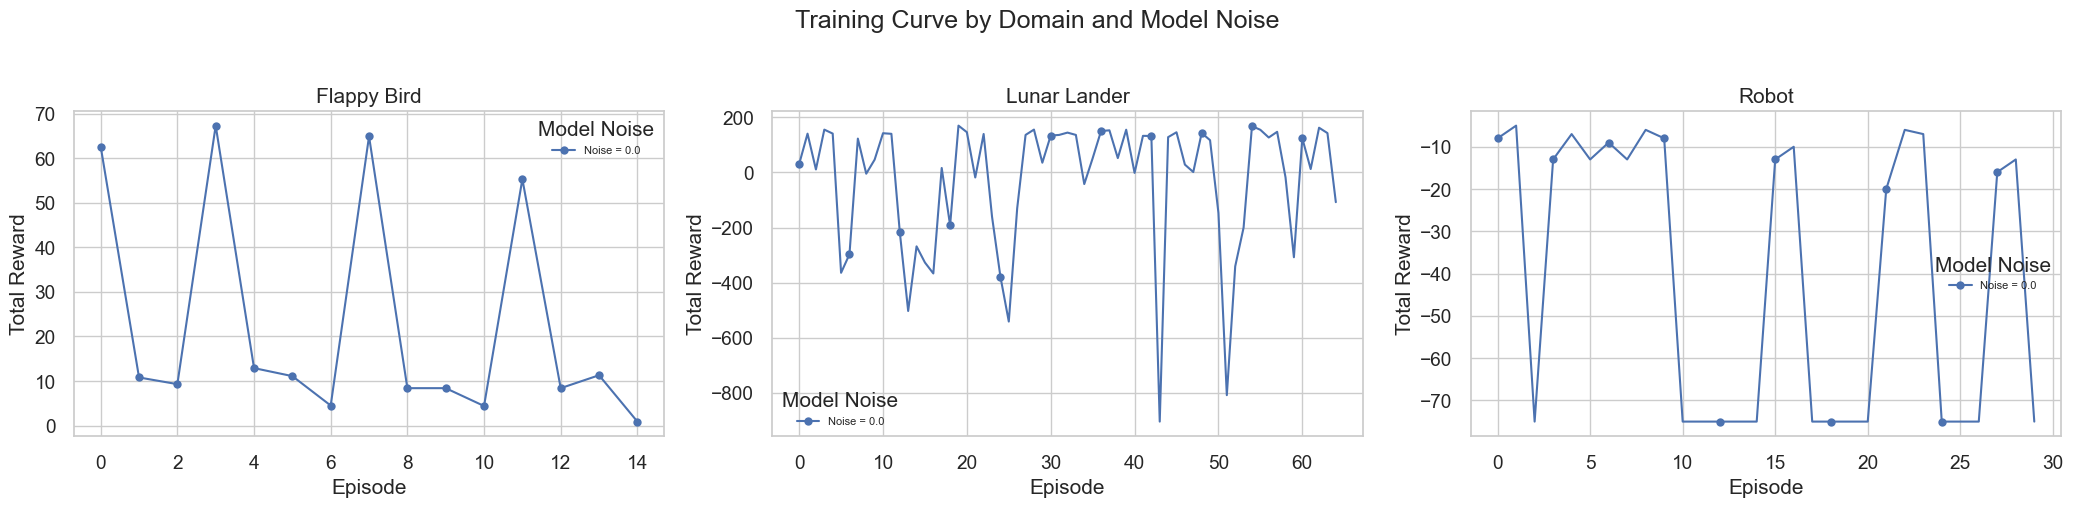

In [31]:
# Group by domain, noise, episode
grouped = exploded.groupby([
    'parameters_experiment_domain',
    'parameters_neural_model_noise',
    'episode'
])['reward_list'].agg(['mean', 'std']).reset_index()

# Get unique domain/task combos -- we would add parameters_experiment_task here if we wanted to also group by task
combos = grouped[['parameters_experiment_domain']].drop_duplicates()
n_plots = len(combos)

fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 5), sharey=False)
if n_plots == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, combos.iterrows()):
    domain = row['parameters_experiment_domain']
    

    subset = grouped[
        (grouped['parameters_experiment_domain'] == domain)
    ]

    for noise in sorted(subset['parameters_neural_model_noise'].unique()):
        noise_data = subset[subset['parameters_neural_model_noise'] == noise].sort_values('episode')
        episodes = noise_data['episode']
        mean = noise_data['mean']
        std = noise_data['std']
 
        line, = ax.plot(episodes, mean, marker='o', markevery=max(1, len(episodes)//10), label=f'Noise = {noise}')
        ax.fill_between(episodes, mean - std, mean + std, alpha=0.2, color=line.get_color())

    ax.set_title(f'{domain}')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.legend(title='Model Noise', fontsize=8)

fig.suptitle('Training Curve by Domain and Model Noise', y=1.02)
plt.tight_layout()
plt.show()

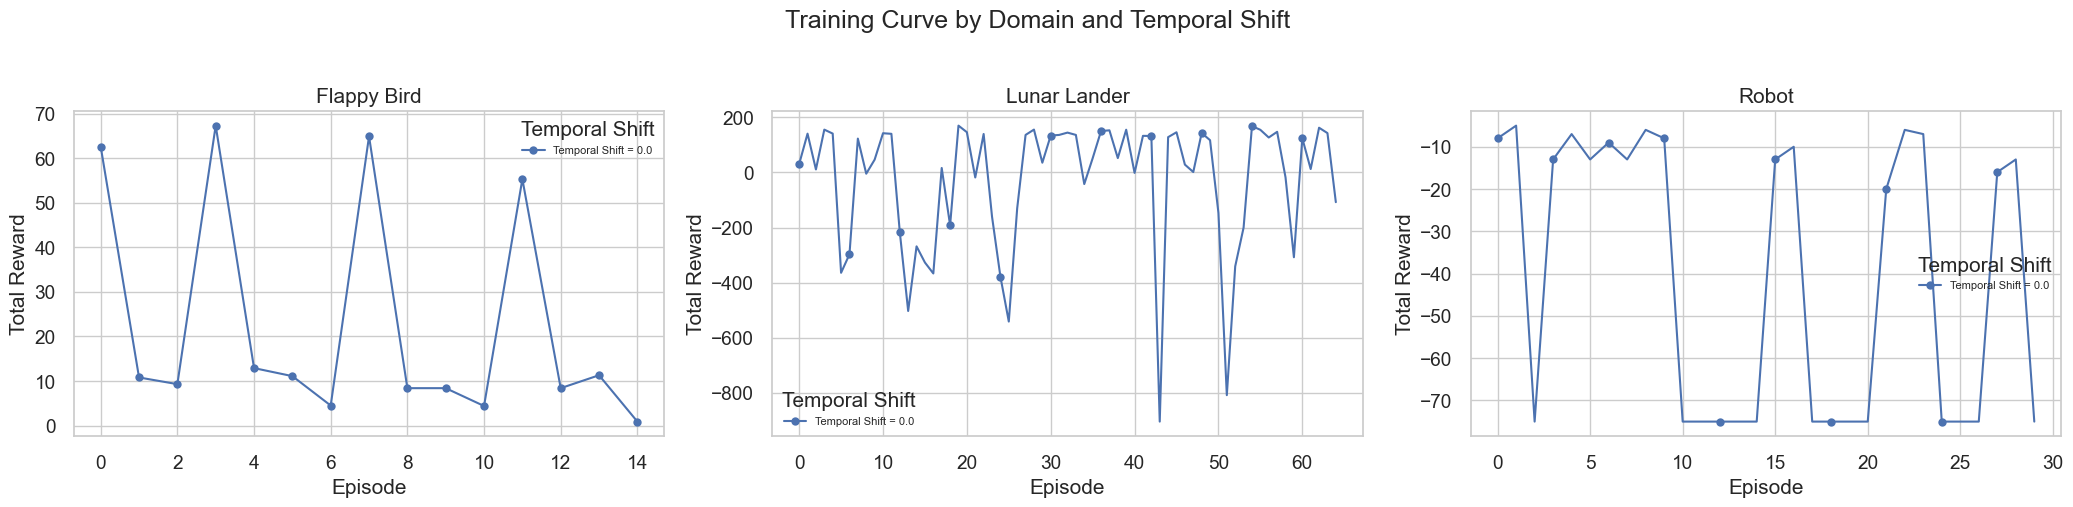

In [32]:
results['reward_list'] = results['results_total_reward'].apply(parse_rewards)

# Explode into per-episode rows
exploded = results.explode('reward_list').copy()
exploded['reward_list'] = exploded['reward_list'].astype(float)
exploded['episode'] = exploded.groupby(level=0)['reward_list'].cumcount()

# Group by domain, shift, episode
grouped = exploded.groupby([
    'parameters_experiment_domain',
    'parameters_neural_temporal_shift',
    'episode'
])['reward_list'].agg(['mean', 'std']).reset_index()

# Get unique domain/task combos
combos = grouped[['parameters_experiment_domain']].drop_duplicates()
n_plots = len(combos)

fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 5), sharey=False)
if n_plots == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, combos.iterrows()):
    domain = row['parameters_experiment_domain']
    

    subset = grouped[
        (grouped['parameters_experiment_domain'] == domain)
    ]

    for shift in sorted(subset['parameters_neural_temporal_shift'].unique()):
        shift_data = subset[subset['parameters_neural_temporal_shift'] == shift].sort_values('episode')
        episodes = shift_data['episode']
        mean = shift_data['mean']
        std = shift_data['std']
 
        line, = ax.plot(episodes, mean, marker='o', markevery=max(1, len(episodes)//10), label=f'Temporal Shift = {shift}')
        ax.fill_between(episodes, mean - std, mean + std, alpha=0.2, color=line.get_color())

    ax.set_title(f'{domain}')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.legend(title='Temporal Shift', fontsize=8)

fig.suptitle('Training Curve by Domain and Temporal Shift', y=1.02)
plt.tight_layout()
plt.show()

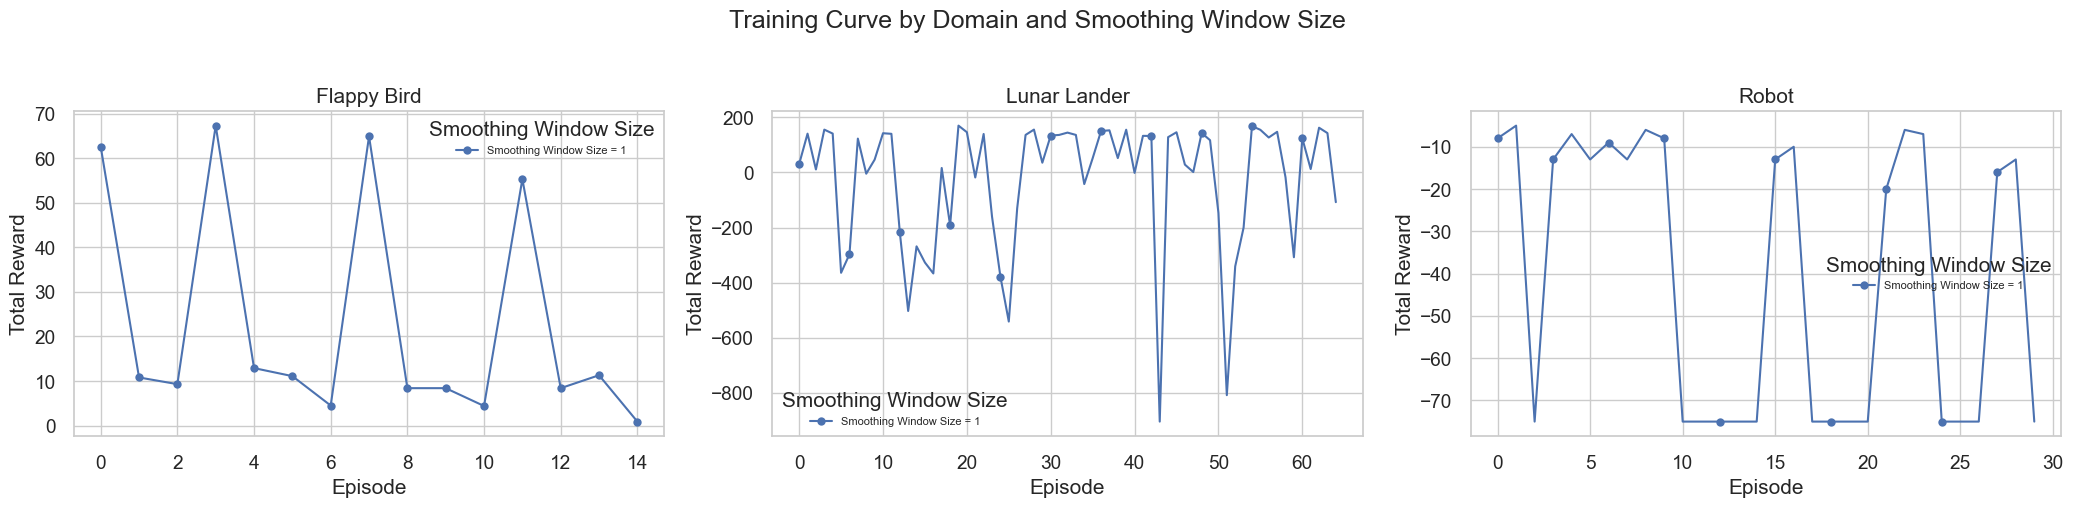

In [33]:
# Group by domain, smoothing window size, episode
grouped = exploded.groupby([
    'parameters_experiment_domain',
    'parameters_neural_smoothing_window_size',
    'episode'
])['reward_list'].agg(['mean', 'std']).reset_index()

# Get unique domain/task combos
combos = grouped[['parameters_experiment_domain']].drop_duplicates()
n_plots = len(combos)

fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 5), sharey=False)
if n_plots == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, combos.iterrows()):
    domain = row['parameters_experiment_domain']
    

    subset = grouped[
        (grouped['parameters_experiment_domain'] == domain)
    ]

    for window_size in sorted(subset['parameters_neural_smoothing_window_size'].unique()):
        window_size_data = subset[subset['parameters_neural_smoothing_window_size'] == window_size].sort_values('episode')
        episodes = window_size_data['episode']
        mean = window_size_data['mean']
        std = window_size_data['std']
 
        line, = ax.plot(episodes, mean, marker='o', markevery=max(1, len(episodes)//10), label=f'Smoothing Window Size = {window_size}')
        ax.fill_between(episodes, mean - std, mean + std, alpha=0.2, color=line.get_color())

    ax.set_title(f'{domain}')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.legend(title='Smoothing Window Size', fontsize=8)

fig.suptitle('Training Curve by Domain and Smoothing Window Size', y=1.02)
plt.tight_layout()
plt.show()

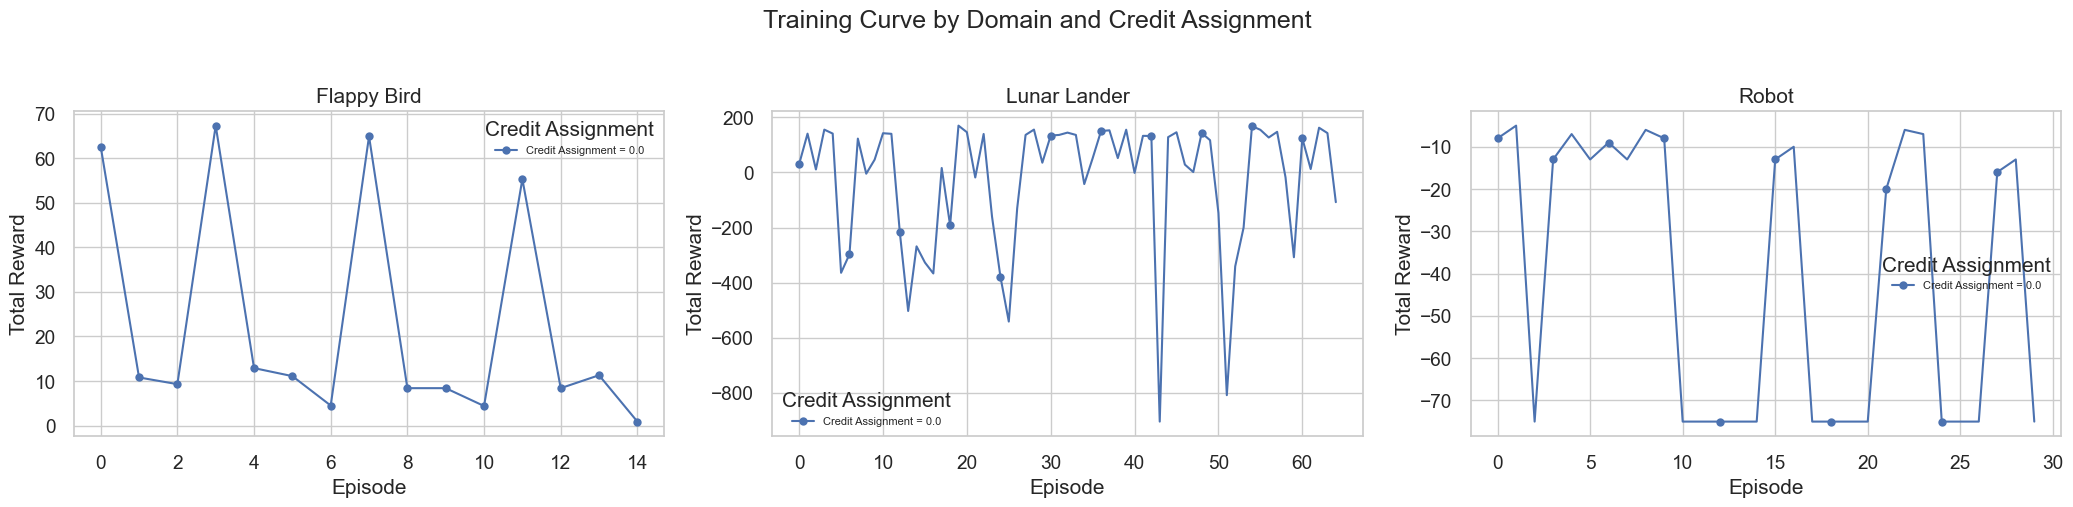

In [34]:
# Group by domain, credit assignment, episode
grouped = exploded.groupby([
    'parameters_experiment_domain',
    'parameters_neural_temporal_shift',
    'episode'
])['reward_list'].agg(['mean', 'std']).reset_index()

# Get unique domain/task combos
combos = grouped[['parameters_experiment_domain']].drop_duplicates()
n_plots = len(combos)

fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 5), sharey=False)
if n_plots == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, combos.iterrows()):
    domain = row['parameters_experiment_domain']
    

    subset = grouped[
        (grouped['parameters_experiment_domain'] == domain)
    ]

    for credit_assignment in sorted(subset['parameters_neural_temporal_shift'].unique()):
        credit_assignment_data = subset[subset['parameters_neural_temporal_shift'] == credit_assignment].sort_values('episode')
        episodes = credit_assignment_data['episode']
        mean = credit_assignment_data['mean']
        std = credit_assignment_data['std']
 
        line, = ax.plot(episodes, mean, marker='o', markevery=max(1, len(episodes)//10), label=f'Credit Assignment = {credit_assignment}')
        ax.fill_between(episodes, mean - std, mean + std, alpha=0.2, color=line.get_color())

    ax.set_title(f'{domain}')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.legend(title='Credit Assignment', fontsize=8)

fig.suptitle('Training Curve by Domain and Credit Assignment', y=1.02)
plt.tight_layout()
plt.show()

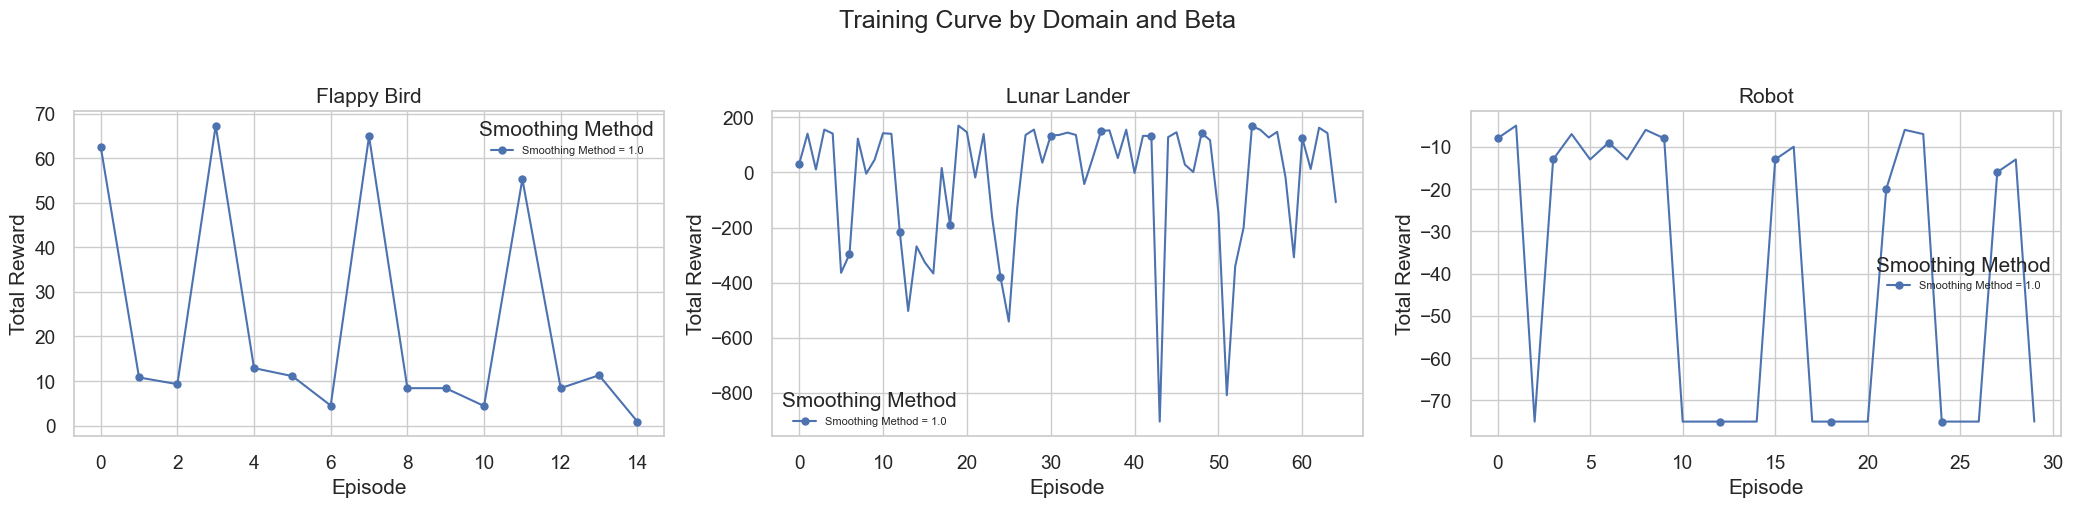

In [35]:
# Group by domain, smoothing method, episode
grouped = exploded.groupby([
    'parameters_experiment_domain',
    'parameters_neural_beta',
    'episode'
])['reward_list'].agg(['mean', 'std']).reset_index()

# Get unique domain/task combos
combos = grouped[['parameters_experiment_domain']].drop_duplicates()
n_plots = len(combos)

fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 5), sharey=False)
if n_plots == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, combos.iterrows()):
    domain = row['parameters_experiment_domain']
    

    subset = grouped[
        (grouped['parameters_experiment_domain'] == domain)
    ]

    for smoothing_method in sorted(subset['parameters_neural_beta'].unique()):
        smoothing_method_data = subset[subset['parameters_neural_beta'] == smoothing_method].sort_values('episode')
        episodes = smoothing_method_data['episode']
        mean = smoothing_method_data['mean']
        std = smoothing_method_data['std']
 
        line, = ax.plot(episodes, mean, marker='o', markevery=max(1, len(episodes)//10), label=f'Smoothing Method = {smoothing_method}')
        ax.fill_between(episodes, mean - std, mean + std, alpha=0.2, color=line.get_color())

    ax.set_title(f'{domain}')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.legend(title='Smoothing Method', fontsize=8)

fig.suptitle('Training Curve by Domain and Beta', y=1.02)
plt.tight_layout()
plt.show()